In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os
import shap
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from feature_engine.transformation import YeoJohnsonTransformer
from xgboost import XGBClassifier

# load data
path = kagglehub.dataset_download("rezaunderfit/instagram-fake-and-real-accounts-dataset")
file_path = os.path.join(path, "final-v1.csv")
df = pd.read_csv(file_path)

target = 'is_fake'
num_features = ['edge_followed_by', 'edge_follow', 'username_length', 'full_name_length']
cat_features = [col for col in df.columns if col not in num_features + [target]]

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Building Preprocessor
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("transformer", YeoJohnsonTransformer()),
    ("scaler", MinMaxScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

# Training XGBoost 
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.7,
        random_state=42,
        eval_metric='logloss'
    ))
])

xgb_model.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [ ]:
# Extracting the trained xgboost model and Transform the training data
xgb_clf = xgb_model.named_steps["model"]
X_train_transformed = xgb_model.named_steps["preprocessor"].transform(X_train)
X_test_transformed = xgb_model.named_steps["preprocessor"].transform(X_test)

# Getting feature names after preprocessing
feature_names = num_features + cat_features

# SHAP explainer
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values computed.")
print("Shape:", shap_values.shape)

SHAP values computed.
Shape: (157, 12)


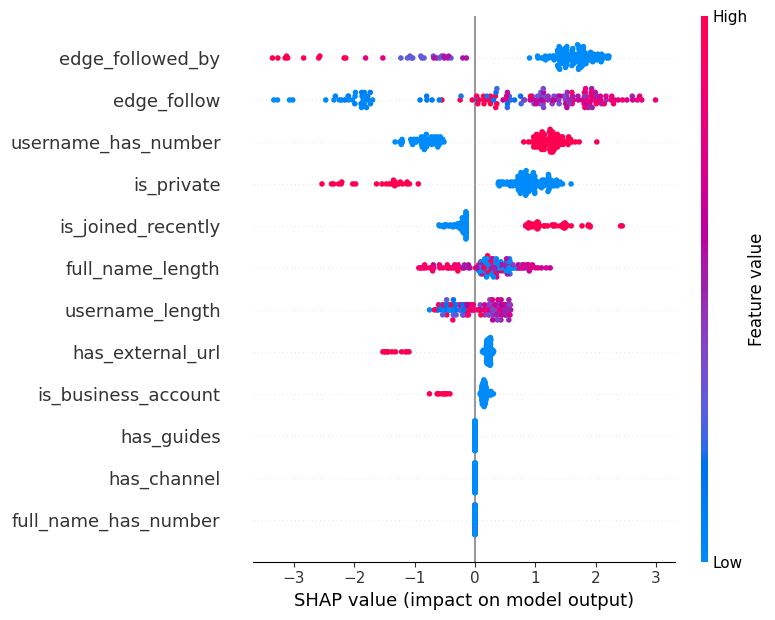

In [ ]:
# Beeswarm Plot for feature importance
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="dot"
)

## SHAP Beeswarm Plot — Feature Impact Analysis

The beeswarm plot shows the SHAP value for each feature across all 157 test accounts. Features are ordered top to bottom by overall importance. Pink/red dots indicate high feature values, blue dots indicate low feature values. Positive SHAP values push toward fake , negative push toward real .

*Key findings:*

- `edge_followed_by` is the strongest predictor — accounts with low follower counts push strongly toward fake, while high follower counts push toward real
- `edge_follow` is the second strongest — accounts following many others push toward fake, consistent with bot behavior of mass-following to gain followers back
- `username_has_number` is the third strongest — usernames containing numbers push toward fake, reflecting common bot naming patterns
- `is_private` — private accounts push toward real, public accounts toward fake
- `has_guides`, `has_channel`, and `full_name_has_number` contribute near-zero impact and could be dropped without meaningfully affecting model performance

Behavioral features like follower/following patterns dominate predictions while profile text features like name length, username length contribute minimally — which is consistent with findings from the EDA.

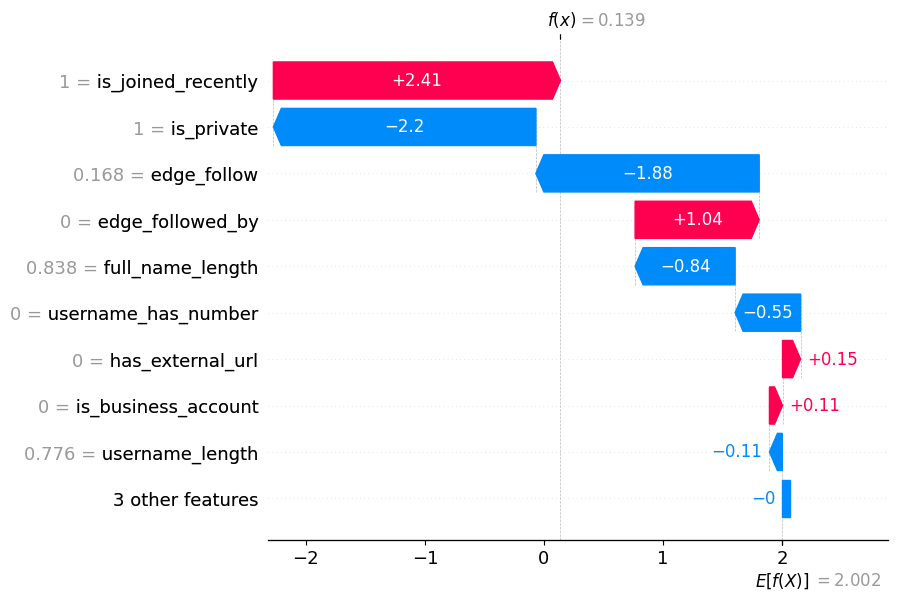

In [7]:
# waterfall plot — single prediction explanation
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test_transformed[0],
        feature_names=feature_names
    )
)

## SHAP Waterfall Plot — Single Prediction Explanation

The waterfall plot explains the model's prediction for one specific account in the test set. Starting from the baseline E[f(X)] = 2.002 (average model output across all accounts), each feature pushes the prediction up(fake_) or down (real) until reaching the final prediction f(x) = 0.139.

*Feature contributions for this account:*

- `is_joined_recently = 1` pushed +2.41 toward fake — strongest signal, recently joined accounts are highly suspicious
- `is_private = 1` pushed -2.2 toward real — private accounts are a strong indicator of authenticity
- `edge_follow = 0.168` pushed -1.88 toward real — low following count looks like real behavior
- `edge_followed_by = 0` pushed +1.04 toward fake — having no followers is suspicious

*Outcome:* Despite being recently joined with no followers, the private account status and low following behavior outweighed the fake signals. Final prediction of 0.139 is well below the 0.5 classification threshold — model classifies this account as *real*.

This plot demonstrates the model's interpretability at the individual prediction level — each decision can be fully explained by its feature contributions rather than treated as a

In [8]:
import joblib

# save the trained pipeline (preprocessor + model together)
joblib.dump(xgb_model, "fake_account_model.pkl")
print("Model saved.")

Model saved.
